# Simulasi Fuzzy Inference System (FIS)

Implementasi **Fuzzy Inference System (FIS)** menggunakan pustaka **`scikit-fuzzy` (`skfuzzy`)** untuk mata kuliah Matematika Sistem Kendali.

### Penjelasan Singkat:
1. Fungsi keanggotaan dibuat dengan `skfuzzy.trapmf`, `skfuzzy.trimf`, dan `skfuzzy.gaussmf`.
2. Fuzzifikasi menggunakan fungsi interpolasi `skfuzzy.interp_membership`.
3. Defuzzifikasi Mamdani menggunakan `skfuzzy.defuzz` (metode `centroid`, `bisector`, `mom`, dll.).
4. Pilihan metode inferensi **`'sugeno'`** (*Weighted Average*) atau **`'mamdani'`** (*Centroid/Center of Gravity*).

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

### 1. Membership Function
- `LinearDownMF`: Linear turun berbasis `fuzz.trapmf(x, [a, a, a, b])`
- `LinearUpMF`: Linear naik berbasis `fuzz.trapmf(x, [a, b, b, b])`
- `TriangularMF`: Segitiga berbasis `fuzz.trimf(x, [a, b, c])`
- `TrapezoidalMF`: Trapesium berbasis `fuzz.trapmf(x, [a, b, c, d])`
- `GaussianMF`: Kurva Gauss berbasis `fuzz.gaussmf(x, mean, sigma)`

In [86]:
class MembershipFunction:
    def __call__(self, x):
        raise NotImplementedError

class LinearDownMF(MembershipFunction):
    def __init__(self, a, b):
        self.a = float(a)  # Batas bawah (mu = 1)
        self.b = float(b)  # Batas atas (mu = 0)

    def __call__(self, x):
        x = np.array(x, dtype=float)
        return fuzz.trapmf(x, [self.a, self.a, self.a, self.b])

class LinearUpMF(MembershipFunction):
    def __init__(self, a, b):
        self.a = float(a)  # Batas bawah (mu = 0)
        self.b = float(b)  # Batas atas (mu = 1)

    def __call__(self, x):
        x = np.array(x, dtype=float)
        return fuzz.trapmf(x, [self.a, self.b, self.b, self.b])

class TriangularMF(MembershipFunction):
    def __init__(self, a, b, c):
        self.a, self.b, self.c = float(a), float(b), float(c)

    def __call__(self, x):
        x = np.array(x, dtype=float)
        return fuzz.trimf(x, [self.a, self.b, self.c])

class TrapezoidalMF(MembershipFunction):
    def __init__(self, a, b, c, d):
        self.a, self.b, self.c, self.d = float(a), float(b), float(c), float(d)

    def __call__(self, x):
        x = np.array(x, dtype=float)
        return fuzz.trapmf(x, [self.a, self.b, self.c, self.d])

class GaussianMF(MembershipFunction):
    def __init__(self, mean, sigma):
        self.mean, self.sigma = float(mean), float(sigma)

    def __call__(self, x):
        x = np.array(x, dtype=float)
        return fuzz.gaussmf(x, self.mean, self.sigma)

### 2. Variabel Fuzzy

In [87]:
class FuzzyVariable:
    def __init__(self, name, domain_min, domain_max, var_type='input', unit='', resolution=1001):
        self.name = name
        self.domain = (float(domain_min), float(domain_max))
        self.var_type = var_type  # 'input' atau 'output'
        self.unit = unit
        self.resolution = resolution
        self.universe = np.linspace(self.domain[0], self.domain[1], resolution)
        self.sets = {}  # {nama_himpunan: membership_function}

    def add_set(self, set_name, mf):
        self.sets[set_name] = mf
        return self

    def fuzzify(self, value):
        result = {}
        for set_name, mf in self.sets.items():
            mf_curve = mf(self.universe)
            mu = float(fuzz.interp_membership(self.universe, mf_curve, float(value)))
            result[set_name] = mu
        return result

### 3. Aturan Fuzzy (Fuzzy Rules)

In [88]:
class FuzzyRule:
    def __init__(self, antecedents, operator, consequent_var, consequent_set, inverse_func=None):
        self.antecedents = antecedents          # [('nama_var', 'nama_set'), ...]
        self.operator = operator.upper()        # 'AND' atau 'OR'
        self.consequent_var = consequent_var    # Nama variabel output
        self.consequent_set = consequent_set    # Nama himpunan konsekuen (Mamdani)
        self.inverse_func = inverse_func        # Fungsi z = f(alpha) atau skalar z untuk Sugeno

    def evaluate(self, fuzzified_inputs):
        doms = [fuzzified_inputs[var][set_name] for var, set_name in self.antecedents]
        if self.operator == 'AND':
            return float(np.min(doms))
        elif self.operator == 'OR':
            return float(np.max(doms))
        raise ValueError(f"Operator '{self.operator}' tidak didukung. Gunakan 'AND' atau 'OR'.")

### 4. Fuzzy Inference System (Sugeno dan Mamdani)

In [89]:
class FuzzyInferenceSystem:
    def __init__(self, method='sugeno', defuzz_method='centroid'):
        method_clean = method.lower().strip()
        if method_clean not in ['sugeno', 'mamdani']:
            raise ValueError(f"Metode '{method}' tidak valid! FIS hanya mendukung metode 'sugeno' atau 'mamdani'.")
        self.method = method_clean
        self.defuzz_method = defuzz_method  # 'centroid', 'bisector', 'mom', 'som', 'lom'
        self.variables = {}
        self.rules = []

    def add_variable(self, var):
        self.variables[var.name] = var
        return self

    def add_rule(self, rule):
        self.rules.append(rule)
        return self

    def compute(self, crisp_inputs):
        # 1. Fuzzifikasi berbasis skfuzzy.interp_membership
        fuzzified = {var_name: self.variables[var_name].fuzzify(val)
                     for var_name, val in crisp_inputs.items()}

        # 2. Evaluasi Aturan & Defuzzifikasi berdasarkan metode
        if self.method == 'sugeno':
            rule_outputs = []
            for rule in self.rules:
                alpha = rule.evaluate(fuzzified)
                # Evaluasi nilai z konsekuen (fungsi atau skalar)
                if callable(rule.inverse_func):
                    try:
                        z = rule.inverse_func(alpha)
                    except TypeError:
                        z = rule.inverse_func(alpha, crisp_inputs)
                elif isinstance(rule.inverse_func, (int, float)):
                    z = float(rule.inverse_func)
                else:
                    raise ValueError(f"Aturan dengan konsekuen {rule.consequent_set} membutuhkan inverse_func/nilai skalar untuk Sugeno.")
                rule_outputs.append((alpha, z))

            # Defuzzifikasi Sugeno: Weighted Average
            total_alpha = sum(alpha for alpha, z in rule_outputs)
            z_star = sum(alpha * z for alpha, z in rule_outputs) / total_alpha if total_alpha > 0 else 0.0
            return z_star, rule_outputs, fuzzified

        elif self.method == 'mamdani':
            out_var_name = self.rules[0].consequent_var
            out_var = self.variables[out_var_name]
            z_vals = out_var.universe
            aggregated = np.zeros_like(z_vals)
            rule_outputs = []

            for rule in self.rules:
                alpha = rule.evaluate(fuzzified)
                mf_curve = out_var.sets[rule.consequent_set](z_vals)
                # Implikasi pemotongan (clipping) dengan np.fmin (standar skfuzzy relation_min)
                clipped_mf = np.fmin(alpha, mf_curve)
                # Agregasi aturan dengan np.fmax (standar skfuzzy fuzzy_or)
                aggregated = np.fmax(aggregated, clipped_mf)
                rule_outputs.append((alpha, rule.consequent_var, rule.consequent_set))

            # Defuzzifikasi terstandarisasi menggunakan skfuzzy.defuzz
            sum_agg = np.sum(aggregated)
            if sum_agg > 0:
                z_star = float(fuzz.defuzz(z_vals, aggregated, self.defuzz_method))
            else:
                z_star = float(np.mean(out_var.domain))

            return z_star, rule_outputs, fuzzified

### 5. Format Output & Modul Visualisasi Grafik Fuzzy

In [90]:
def print_simulation_results(fis, crisp_inputs, z_star, rule_outputs, fuzzified, title="HASIL SIMULASI FUZZY INFERENCE SYSTEM (KASUS ABC)", unit="kemasan/hari"):
    method_label = "Sugeno (Weighted Average)" if fis.method == 'sugeno' else f"Mamdani ({fis.defuzz_method.capitalize()})"
    input_str = ", ".join([f"{k} = {v}" for k, v in crisp_inputs.items()])

    print("=" * 60)
    print(f"      {title}")
    print("=" * 60)
    print(f"Metode FIS  : {method_label}")
    print(f"Input Crisp : {input_str}")
    print("-" * 60)
    print("1. Fuzzifikasi:")
    for var, sets in fuzzified.items():
        print(f"   [{var}] -> " + ", ".join([f"{k}: {v:.4f}" for k, v in sets.items()]))
    print("-" * 60)
    if fis.method == 'sugeno':
        print("2. Evaluasi Aturan (Firing Strength & z_i):")
        for idx, (alpha, z) in enumerate(rule_outputs, start=1):
            print(f"   * Rule R{idx} -> alpha_{idx} = {alpha:.4f}, z_{idx} = {z:.2f}")
    else:
        print("2. Evaluasi Aturan (Firing Strength & Konsekuen):")
        for idx, (alpha, var_name, set_name) in enumerate(rule_outputs, start=1):
            print(f"   * Rule R{idx} -> alpha_{idx} = {alpha:.4f}, Konsekuen: {var_name} {set_name}")
    print("-" * 60)
    print(f"3. Hasil Akhir Defuzzifikasi: z* = {z_star:.2f} {unit}")
    print("=" * 60)

def plot_membership_functions(fis, crisp_inputs=None):
    n_vars = len(fis.variables)
    fig, axes = plt.subplots(n_vars, 1, figsize=(9, 2.8 * n_vars), sharey=True)
    if n_vars == 1:
        axes = [axes]

    palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for ax, (var_name, var) in zip(axes, fis.variables.items()):
        x_vals = var.universe
        for i, (set_name, mf) in enumerate(var.sets.items()):
            color = palette[i % len(palette)]
            y_vals = mf(x_vals)
            ax.plot(x_vals, y_vals, label=set_name, linewidth=2, color=color)

        unit_str = f" ({var.unit})" if var.unit else ""
        ax.set_title(f"Fungsi Keanggotaan: {var_name}{unit_str}", fontsize=11, fontweight='bold')
        ax.set_xlabel(f"{var_name}{unit_str}")
        ax.set_ylabel(r"Derajat ($\mu$)")
        ax.set_ylim(-0.05, 1.08)
        ax.grid(True, linestyle=':', alpha=0.6)

        # Plot garis nilai input crisp dan anotasi derajat keanggotaan
        if crisp_inputs and var_name in crisp_inputs:
            x_val = crisp_inputs[var_name]
            ax.axvline(x_val, color='#e74c3c', linestyle='--', linewidth=1.8, label=f"Input: {x_val}")
            for set_name, mf in var.sets.items():
                mu_val = float(fuzz.interp_membership(var.universe, mf(var.universe), float(x_val)))
                ax.plot(x_val, mu_val, 'o', color='#e74c3c', markersize=6)
                ax.annotate(f"{set_name}: {mu_val:.2f}",
                            (x_val, mu_val),
                            textcoords="offset points",
                            xytext=(8, 4),
                            fontsize=9,
                            fontweight='bold',
                            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#e74c3c", alpha=0.8))
        ax.legend(loc='upper right', framealpha=0.85)

    plt.tight_layout()
    plt.show()

def plot_defuzzification(fis, crisp_inputs, z_star, rule_outputs, fuzzified):
    out_var_name = fis.rules[0].consequent_var
    out_var = fis.variables[out_var_name]
    z_min, z_max = out_var.domain
    z_vals = out_var.universe

    fig, ax = plt.subplots(figsize=(9, 4.2))

    if fis.method == 'mamdani':
        for set_name, mf in out_var.sets.items():
            ax.plot(z_vals, mf(z_vals), '--', alpha=0.45, linewidth=1.5, label=f"MF Asli: {set_name}")

        aggregated = np.zeros_like(z_vals)
        for alpha, v_name, set_name in rule_outputs:
            mf_curve = out_var.sets[set_name](z_vals)
            clipped = np.fmin(alpha, mf_curve)
            aggregated = np.fmax(aggregated, clipped)

        ax.fill_between(z_vals, aggregated, color='#2ecc71', alpha=0.35, label='Area Agregasi Terpotong (Max-Min)')
        ax.plot(z_vals, aggregated, color='#27ae60', linewidth=2)

        unit_str = f" {out_var.unit}" if out_var.unit else ""
        ax.axvline(z_star, color='#c0392b', linestyle='-', linewidth=2.5,
                   label=f"Centroid z* = {z_star:.2f}{unit_str}")
        ax.set_title(f"Defuzzifikasi Mamdani (skfuzzy.defuzz 'centroid') - {out_var_name}", fontsize=11, fontweight='bold')

    elif fis.method == 'sugeno':
        rule_z = [z for alpha, z in rule_outputs]
        rule_a = [alpha for alpha, z in rule_outputs]

        markerline, stemlines, baseline = ax.stem(rule_z, rule_a, linefmt='b-', markerfmt='bo', basefmt='k-')
        plt.setp(stemlines, linewidth=1.8)
        plt.setp(markerline, markersize=8)

        for i, (alpha, z) in enumerate(rule_outputs, 1):
            ax.annotate(f"R{i} (z={z:.1f}, α={alpha:.2f})", (z, alpha),
                        textcoords="offset points", xytext=(0, 6), ha='center', fontsize=8.5, fontweight='bold')

        unit_str = f" {out_var.unit}" if out_var.unit else ""
        ax.axvline(z_star, color='#c0392b', linestyle='-', linewidth=2.5,
                   label=f"Weighted Avg z* = {z_star:.2f}{unit_str}")
        ax.set_title(f"Defuzzifikasi Sugeno (Weighted Average) - {out_var_name}", fontsize=11, fontweight='bold')
        ax.set_xlim(z_min - 0.05 * (z_max - z_min), z_max + 0.05 * (z_max - z_min))

    unit_str = f" ({out_var.unit})" if out_var.unit else ""
    ax.set_xlabel(f"{out_var_name}{unit_str}")
    ax.set_ylabel(r"Firing Strength ($\alpha$) / Keanggotaan")
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

def run_simulation(fis, crisp_inputs, title="HASIL SIMULASI FUZZY INFERENCE SYSTEM"):
    z_star, rule_outputs, fuzzified = fis.compute(crisp_inputs)
    out_var_name = fis.rules[0].consequent_var
    unit = fis.variables[out_var_name].unit if hasattr(fis.variables[out_var_name], 'unit') else ""
    print_simulation_results(fis, crisp_inputs, z_star, rule_outputs, fuzzified, title=title, unit=unit)
    plot_membership_functions(fis, crisp_inputs)
    plot_defuzzification(fis, crisp_inputs, z_star, rule_outputs, fuzzified)
    return z_star, rule_outputs, fuzzified

### 6. Studi Kasus 1: Produksi Makanan Kaleng ABC
Penerapan sistem inferensi fuzzy pada masalah produksi makanan kaleng ABC:
- **DEMAND**: 1000-5000 kemasan/hari (Himpunan: `DECREASE`, `INCREASE`)
- **INVENTORY**: 100-600 kemasan/hari (Himpunan: `FEW`, `MANY`)
- **PRODUCTION (Output)**: 2000-7000 kemasan/hari (Himpunan: `DECREASE`, `INCREASE`)

*Rule Base*:
- [R1] IF DEMAND DECREASE AND INVENTORY MANY THEN PRODUCTION DECREASE
- [R2] IF DEMAND DECREASE AND INVENTORY FEW THEN PRODUCTION DECREASE
- [R3] IF DEMAND INCREASE AND INVENTORY MANY THEN PRODUCTION INCREASE
- [R4] IF DEMAND INCREASE AND INVENTORY FEW THEN PRODUCTION INCREASE

In [91]:
def build_abc_case_fis(method='sugeno', defuzz_method='centroid'):
    fis = FuzzyInferenceSystem(method=method, defuzz_method=defuzz_method)

    # --- Variabel Demand (1000 - 5000) ---
    demand = FuzzyVariable('Demand', 1000, 5000, var_type='input', unit='kemasan/hari')
    demand.add_set('DECREASE', LinearDownMF(1000, 5000))
    demand.add_set('INCREASE', LinearUpMF(1000, 5000))
    fis.add_variable(demand)

    # --- Variabel inventory (100 - 600) ---
    inventory = FuzzyVariable('Inventory', 100, 600, var_type='input', unit='kemasan/hari')
    inventory.add_set('FEW', LinearDownMF(100, 600))
    inventory.add_set('MANY', LinearUpMF(100, 600))
    fis.add_variable(inventory)

    # --- C. Variabel production (2000 - 7000) ---
    production = FuzzyVariable('Production', 2000, 7000, var_type='output', unit='kemasan/hari')
    production.add_set('DECREASE', LinearDownMF(2000, 7000))
    production.add_set('INCREASE', LinearUpMF(2000, 7000))
    fis.add_variable(production)

    # --- D. Fungsi Invers z = f(alpha) untuk Sugeno ---
    inv_berkurang = lambda alpha: 7000.0 - (alpha * 5000.0)
    inv_bertambah = lambda alpha: 2000.0 + (alpha * 5000.0)

    # --- E. Rule Base (R1 - R4) ---
    fis.add_rule(FuzzyRule([('Demand', 'DECREASE'), ('Inventory', 'MANY')], 'AND', 'Production', 'DECREASE', inv_berkurang))
    fis.add_rule(FuzzyRule([('Demand', 'DECREASE'), ('Inventory', 'FEW')], 'AND', 'Production', 'DECREASE', inv_berkurang))
    fis.add_rule(FuzzyRule([('Demand', 'INCREASE'), ('Inventory', 'MANY')], 'AND', 'Production', 'INCREASE', inv_bertambah))
    fis.add_rule(FuzzyRule([('Demand', 'INCREASE'), ('Inventory', 'FEW')], 'AND', 'Production', 'INCREASE', inv_bertambah))

    return fis

### 7. Simulasi Kasus ABC: Metode Sugeno & Mamdani
Pengujian dilakukan dengan nilai input:
- **Permintaan** = 4000
- **Persediaan** = 300

Berikut adalah hasil eksekusi kedua metode dan perbandingannya dengan `skfuzzy.control.ControlSystemSimulation`.

METODE SUGENO
      HASIL SIMULASI FIS SUGENO (KASUS ABC)
Metode FIS  : Sugeno (Weighted Average)
Input Crisp : Demand = 4000, Inventory = 300
------------------------------------------------------------
1. Fuzzifikasi:
   [Demand] -> DECREASE: 0.2500, INCREASE: 0.7500
   [Inventory] -> FEW: 0.6000, MANY: 0.4000
------------------------------------------------------------
2. Evaluasi Aturan (Firing Strength & z_i):
   * Rule R1 -> alpha_1 = 0.2500, z_1 = 5750.00
   * Rule R2 -> alpha_2 = 0.2500, z_2 = 5750.00
   * Rule R3 -> alpha_3 = 0.4000, z_3 = 4000.00
   * Rule R4 -> alpha_4 = 0.6000, z_4 = 5000.00
------------------------------------------------------------
3. Hasil Akhir Defuzzifikasi: z* = 4983.33 kemasan/hari


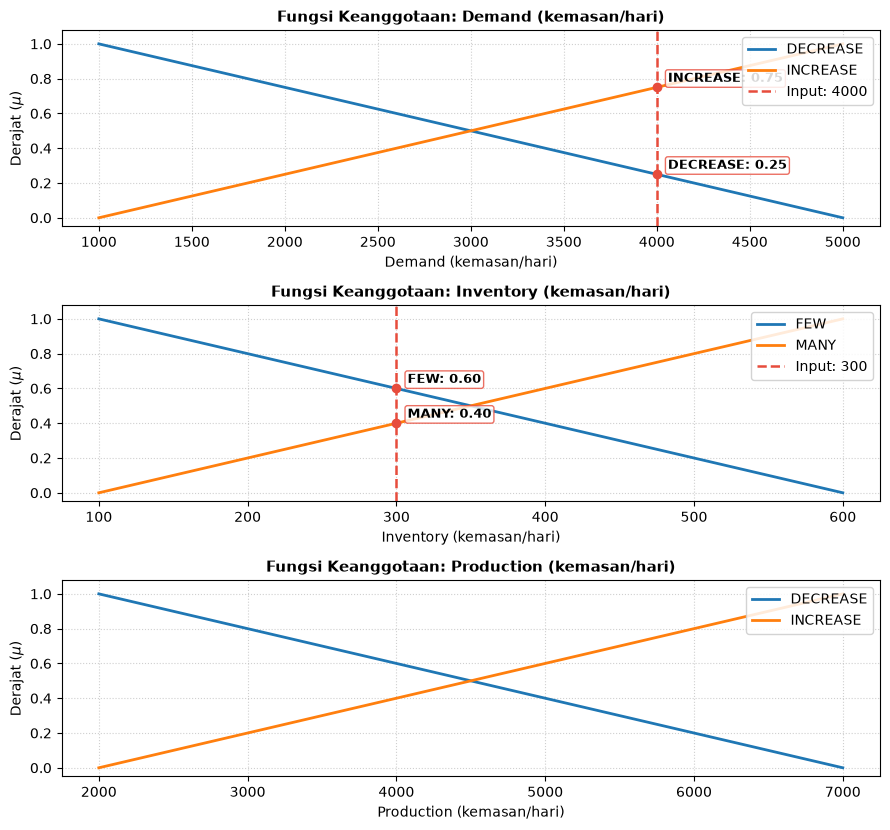

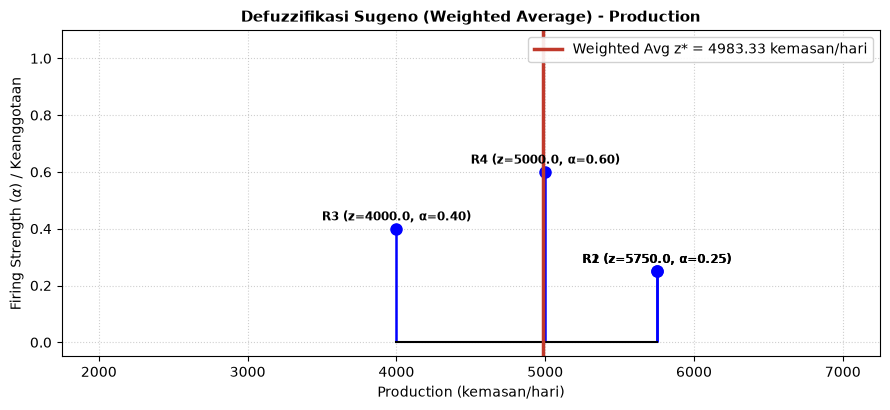



METODE MAMDANI
      HASIL SIMULASI FIS MAMDANI (KASUS ABC)
Metode FIS  : Mamdani (Centroid)
Input Crisp : Demand = 4000, Inventory = 300
------------------------------------------------------------
1. Fuzzifikasi:
   [Demand] -> DECREASE: 0.2500, INCREASE: 0.7500
   [Inventory] -> FEW: 0.6000, MANY: 0.4000
------------------------------------------------------------
2. Evaluasi Aturan (Firing Strength & Konsekuen):
   * Rule R1 -> alpha_1 = 0.2500, Konsekuen: Production DECREASE
   * Rule R2 -> alpha_2 = 0.2500, Konsekuen: Production DECREASE
   * Rule R3 -> alpha_3 = 0.4000, Konsekuen: Production INCREASE
   * Rule R4 -> alpha_4 = 0.6000, Konsekuen: Production INCREASE
------------------------------------------------------------
3. Hasil Akhir Defuzzifikasi: z* = 4954.06 kemasan/hari


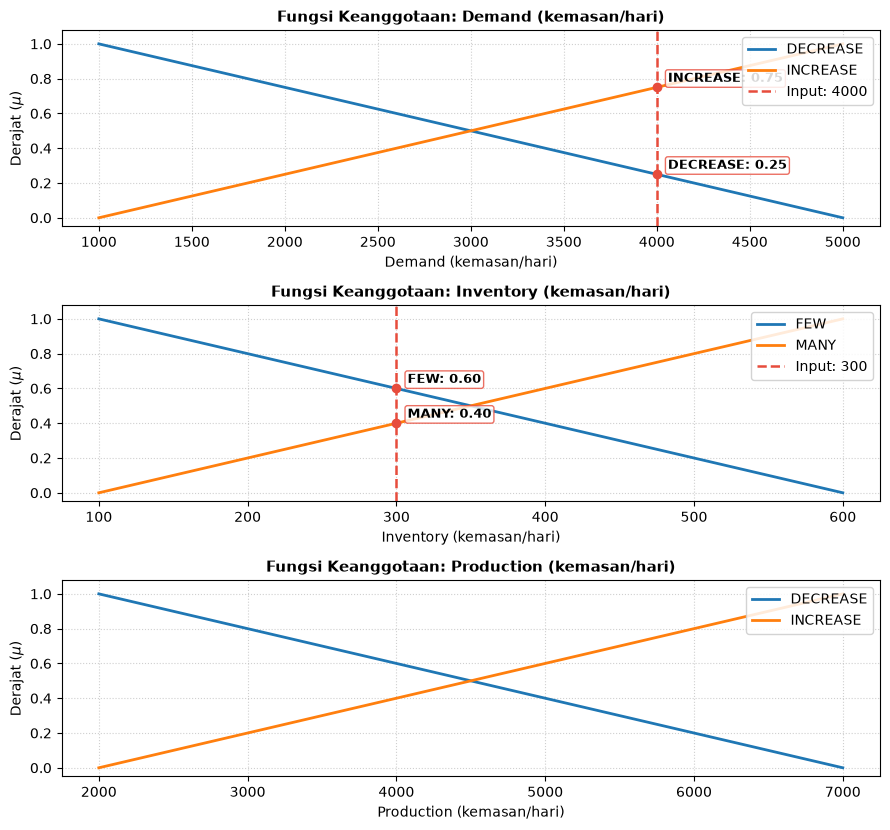

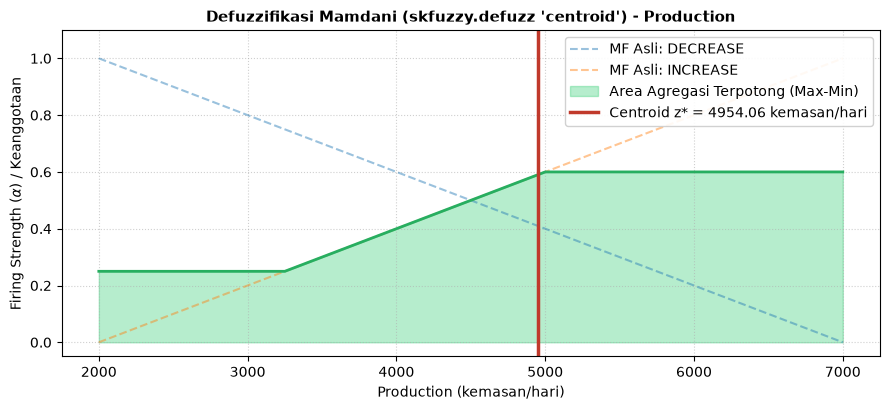

In [92]:
input_data_abc = {'Demand': 4000, 'Inventory': 300}

print("METODE SUGENO")
fis_sugeno = build_abc_case_fis(method='sugeno')
z_sugeno, _, _ = run_simulation(fis_sugeno, input_data_abc, title="HASIL SIMULASI FIS SUGENO (KASUS ABC)")

print("\n" + "=" * 60 + "\n")

print("METODE MAMDANI")
fis_mamdani = build_abc_case_fis(method='mamdani', defuzz_method='centroid')
z_mamdani, _, _ = run_simulation(fis_mamdani, input_data_abc, title="HASIL SIMULASI FIS MAMDANI (KASUS ABC)")